# 03 Strategy Comparison: Efficient Frontier, Benchmarks, and Recommendation

This notebook consumes `outputs/tables/baseline_strategy_results.csv` (produced by `02_baseline_strategies.ipynb`) and turns the baseline grid search into a decision. It builds:

- an efficient-frontier view of execution cost vs. delta risk across every static-band configuration in the grid;
- benchmark comparisons against the zero-hedge and full-hedge extremes;
- sensitivity tables for band width, execution horizon, impact-cost parameters, and the risk-penalty weight;
- an intraday walk-through of how book delta -- and the resulting delta PnL -- actually evolves under each strategy;
- a final recommendation for the baseline static-band policy.

Primary input: `outputs/tables/baseline_strategy_results.csv`.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUT_TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
OUTPUT_FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'

RESULTS_PATH = OUTPUT_TABLE_DIR / 'baseline_strategy_results.csv'
DELTA_ARRIVALS_PATH = PROCESSED_DIR / 'executed_trade_delta_arrivals.csv'
MARKET_INPUTS_PATH = PROCESSED_DIR / 'market_inputs_2026.csv'

# Fixed simulation constants from 02_baseline_strategies.ipynb (needed to
# recompute combined_loss and rescale costs for the sensitivity grids below).
# Deltas and hedge quantities are in ES futures contracts; ES_MULTIPLIER
# ($50 per index point per contract) converts point PnL to dollars.
ES_MULTIPLIER = 50
BAR_MINUTES = 5
SPREAD_BPS = 1.0
IMPACT_ALPHA = 0.05
IMPACT_BETA = 0.5
LAMBDA_RISK = 1e-8

# Chart palette (validated categorical + ordinal ramps).
SURFACE = '#fcfcfb'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID_COLOR = '#e1e0d9'
COLOR_ZERO_HEDGE = '#2a78d6'
COLOR_FULL_HEDGE = '#1baf7a'
COLOR_STATIC_BAND = '#eda100'
BAND_RAMP = ['#dba149', '#cf8a1f', '#b87200', '#965d00']  # ordinal: light -> dark as band widens

print(PROJECT_ROOT)

C:\Users\chung\Downloads\JPM delta hedging project\JPM_Optimal_Intraday_Delta_Hedging_Strategy


## 2. Load Baseline Strategy Results

In [2]:
results_df = pd.read_csv(RESULTS_PATH)
results_df['trade_date'] = pd.to_datetime(results_df['trade_date'])

n_days = results_df['trade_date'].nunique()
print(f'Strategy-day records: {len(results_df):,} across {n_days:,} trading days')
results_df.head()

Strategy-day records: 2,652 across 102 trading days


,trade_date,strategy,band,method,horizon_minutes,execution_cost,spread_cost,impact_cost,delta_risk,combined_loss,n_triggers,total_abs_hedge_delta,eod_delta_before_flatten
0,2026-01-02,zero_hedge,NaN,close_only,0,10527.530387,414.135000,10113.395387,73.101563,10527.530388,0,24.0,24.144509
1,2026-01-02,full_hedge,0.0,immediate,0,40417.268617,2655.366875,37761.901742,0.011575,40417.268617,33,154.0,0.144509
2,2026-01-02,static_band,500.0,twap,15,10527.530387,414.135000,10113.395387,73.101563,10527.530388,0,24.0,24.144509
3,2026-01-02,static_band,500.0,twap,30,10527.530387,414.135000,10113.395387,73.101563,10527.530388,0,24.0,24.144509
4,2026-01-02,static_band,500.0,twap,60,10527.530387,414.135000,10113.395387,73.101563,10527.530388,0,24.0,24.144509


## 3. Aggregate Across Days by Strategy Configuration

In [3]:
config_summary = (
    results_df.groupby(['strategy', 'band', 'method', 'horizon_minutes'], dropna=False)
    .agg(
        execution_cost=('execution_cost', 'sum'),
        spread_cost=('spread_cost', 'sum'),
        impact_cost=('impact_cost', 'sum'),
        delta_risk=('delta_risk', 'sum'),
        combined_loss=('combined_loss', 'sum'),
        n_triggers=('n_triggers', 'sum'),
        total_abs_hedge_delta=('total_abs_hedge_delta', 'sum'),
        avg_eod_delta_before_flatten=('eod_delta_before_flatten', 'mean'),
    )
    .reset_index()
    .sort_values('combined_loss')
)

zero_hedge = config_summary.loc[config_summary['strategy'].eq('zero_hedge')].iloc[0]
full_hedge = config_summary.loc[config_summary['strategy'].eq('full_hedge')].iloc[0]
static_band = config_summary.loc[config_summary['strategy'].eq('static_band')].copy()
best_static = static_band.sort_values('combined_loss').iloc[0]

config_summary.head(10)

,strategy,band,method,horizon_minutes,execution_cost,spread_cost,impact_cost,delta_risk,combined_loss,n_triggers,total_abs_hedge_delta,avg_eod_delta_before_flatten
3,static_band,500.0,twap,60,1.383818e+06,133198.371250,1.250620e+06,181774.268692,1.383818e+06,3,7604.0,5.016767
6,static_band,500.0,vwap,60,1.387161e+06,133198.495625,1.253962e+06,180763.131784,1.387161e+06,2,7604.0,5.016767
2,static_band,500.0,twap,30,1.413974e+06,133198.309375,1.280776e+06,180125.236293,1.413974e+06,1,7604.0,5.928532
5,static_band,500.0,vwap,30,1.416372e+06,133198.386250,1.283173e+06,180225.598692,1.416372e+06,1,7604.0,5.928532
1,static_band,500.0,twap,15,1.446896e+06,133198.902500,1.313697e+06,178687.783457,1.446896e+06,1,7604.0,5.928532
4,static_band,500.0,vwap,15,1.448239e+06,133198.572500,1.315041e+06,178532.593889,1.448239e+06,1,7604.0,5.928532
7,static_band,1000.0,twap,15,1.573752e+06,133189.787500,1.440562e+06,251665.797568,1.573752e+06,0,7604.0,11.036375
8,static_band,1000.0,twap,30,1.573752e+06,133189.787500,1.440562e+06,251665.797568,1.573752e+06,0,7604.0,11.036375
12,static_band,1000.0,vwap,60,1.573752e+06,133189.787500,1.440562e+06,251665.797568,1.573752e+06,0,7604.0,11.036375
9,static_band,1000.0,twap,60,1.573752e+06,133189.787500,1.440562e+06,251665.797568,1.573752e+06,0,7604.0,11.036375


## 4. Efficient Frontier: Execution Cost vs. Delta Risk

Each point below is one static-band configuration (band width x execution method x horizon), aggregated over the full backtest period. Band is an ordinal, magnitude-like variable, so it is encoded as a single-hue ramp (light = tight band, dark = wide band); execution method is encoded separately by marker shape so the two dimensions don't compete for the same channel. The zero-hedge and full-hedge benchmarks are overlaid as stars. The dashed line traces the Pareto frontier -- configurations where no other point has both lower cost and lower risk.

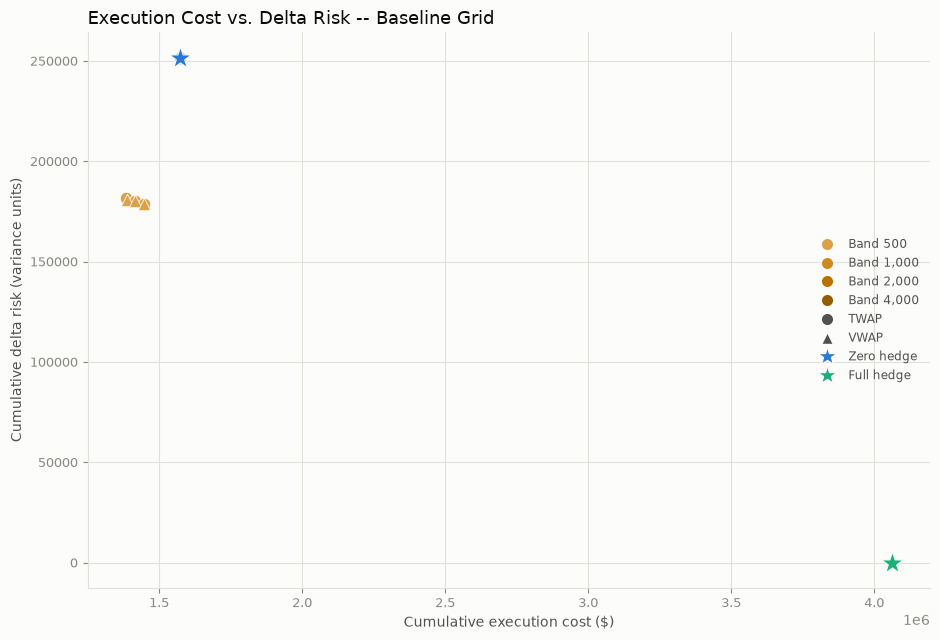

Wrote figure to outputs\figures\efficient_frontier_cost_vs_risk.png
Pareto-efficient configs: 5 of 24


,band,method,horizon_minutes,execution_cost,delta_risk,combined_loss
0,500.0,twap,60,1.383818e+06,181774.268692,1.383818e+06
1,500.0,vwap,60,1.387161e+06,180763.131784,1.387161e+06
2,500.0,twap,30,1.413974e+06,180125.236293,1.413974e+06
4,500.0,twap,15,1.446896e+06,178687.783457,1.446896e+06
5,500.0,vwap,15,1.448239e+06,178532.593889,1.448239e+06


In [4]:
BAND_ORDER = sorted(static_band['band'].unique())
BAND_COLORS = dict(zip(BAND_ORDER, BAND_RAMP))
METHOD_MARKERS = {'twap': 'o', 'vwap': '^'}


def pareto_frontier(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    """Non-dominated points when minimizing both x_col and y_col."""
    ordered = df.sort_values([x_col, y_col]).reset_index(drop=True)
    keep = []
    best_y = np.inf
    for i, row in ordered.iterrows():
        if row[y_col] < best_y:
            keep.append(i)
            best_y = row[y_col]
    return ordered.loc[keep]


frontier = pareto_frontier(static_band, 'execution_cost', 'delta_risk')

fig, ax = plt.subplots(figsize=(9.5, 6.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

for band in BAND_ORDER:
    for method, marker in METHOD_MARKERS.items():
        subset = static_band.loc[static_band['band'].eq(band) & static_band['method'].eq(method)]
        ax.scatter(
            subset['execution_cost'], subset['delta_risk'], color=BAND_COLORS[band], marker=marker,
            s=80, edgecolor=SURFACE, linewidth=0.6, zorder=3,
        )

ax.plot(frontier['execution_cost'], frontier['delta_risk'], color=INK_MUTED, linewidth=1, linestyle='--', zorder=2)

ax.scatter(zero_hedge['execution_cost'], zero_hedge['delta_risk'], color=COLOR_ZERO_HEDGE, marker='*', s=280, edgecolor=SURFACE, linewidth=0.8, zorder=4)
ax.scatter(full_hedge['execution_cost'], full_hedge['delta_risk'], color=COLOR_FULL_HEDGE, marker='*', s=280, edgecolor=SURFACE, linewidth=0.8, zorder=4)

band_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', markerfacecolor=BAND_COLORS[band], markeredgecolor=SURFACE, markersize=9, label=f'Band {band:,.0f}')
    for band in BAND_ORDER
]
method_handles = [
    plt.Line2D([0], [0], marker=marker, linestyle='', markerfacecolor=INK_SECONDARY, markeredgecolor=SURFACE, markersize=9, label=method.upper())
    for method, marker in METHOD_MARKERS.items()
]
benchmark_handles = [
    plt.Line2D([0], [0], marker='*', linestyle='', markerfacecolor=COLOR_ZERO_HEDGE, markeredgecolor=SURFACE, markersize=15, label='Zero hedge'),
    plt.Line2D([0], [0], marker='*', linestyle='', markerfacecolor=COLOR_FULL_HEDGE, markeredgecolor=SURFACE, markersize=15, label='Full hedge'),
]

legend = ax.legend(handles=band_handles + method_handles + benchmark_handles, loc='center right', frameon=False, fontsize=8.5)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

ax.set_title('Execution Cost vs. Delta Risk -- Baseline Grid', color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_xlabel('Cumulative execution cost ($)', color=INK_SECONDARY, fontsize=10)
ax.set_ylabel('Cumulative delta risk (variance units)', color=INK_SECONDARY, fontsize=10)
ax.grid(color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'efficient_frontier_cost_vs_risk.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')
print(f'Pareto-efficient configs: {len(frontier)} of {len(static_band)}')
frontier[['band', 'method', 'horizon_minutes', 'execution_cost', 'delta_risk', 'combined_loss']]

## 5. Benchmark Comparison vs. Zero Hedge and Full Hedge

The panels below compare the best static-band configuration (lowest `combined_loss`) against the two benchmarks on each objective separately -- cost and risk sit on different scales, so they get their own axes rather than a dual-axis chart.

In [5]:
benchmark_table = pd.DataFrame([
    {'strategy': 'Zero hedge', 'execution_cost': zero_hedge['execution_cost'], 'delta_risk': zero_hedge['delta_risk'], 'combined_loss': zero_hedge['combined_loss']},
    {'strategy': 'Full hedge', 'execution_cost': full_hedge['execution_cost'], 'delta_risk': full_hedge['delta_risk'], 'combined_loss': full_hedge['combined_loss']},
    {
        'strategy': f"Static band {best_static['band']:,.0f} ({best_static['method'].upper()}, {best_static['horizon_minutes']}min)",
        'execution_cost': best_static['execution_cost'], 'delta_risk': best_static['delta_risk'], 'combined_loss': best_static['combined_loss'],
    },
])
benchmark_table['cost_vs_zero_hedge_pct'] = (benchmark_table['execution_cost'] / zero_hedge['execution_cost'] - 1) * 100
benchmark_table['risk_vs_zero_hedge_pct'] = (benchmark_table['delta_risk'] / zero_hedge['delta_risk'] - 1) * 100
benchmark_table['cost_vs_full_hedge_pct'] = (benchmark_table['execution_cost'] / full_hedge['execution_cost'] - 1) * 100

benchmark_table

,strategy,execution_cost,delta_risk,combined_loss,cost_vs_zero_hedge_pct,risk_vs_zero_hedge_pct,cost_vs_full_hedge_pct
0,Zero hedge,1.573752e+06,251665.797568,1.573752e+06,0.000000,0.000000,-61.249315
1,Full hedge,4.061224e+06,2.377513,4.061224e+06,158.059955,-99.999055,0.000000
2,"Static band 500 (TWAP, 60min)",1.383818e+06,181774.268692,1.383818e+06,-12.068866,-27.771564,-65.926083


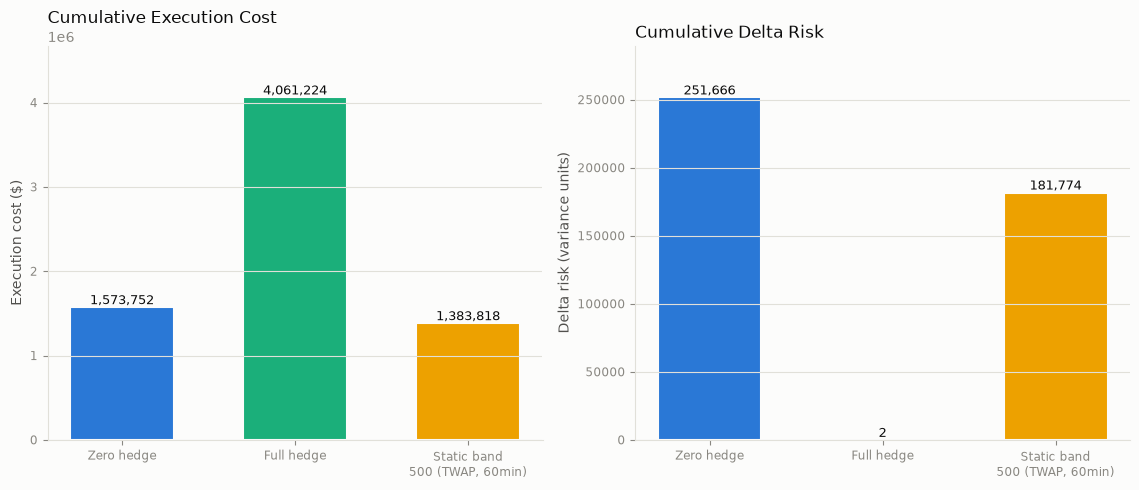

Wrote figure to outputs\figures\benchmark_comparison_cost_risk.png


In [6]:
labels = ['Zero hedge', 'Full hedge', f"Static band\n{best_static['band']:,.0f} ({best_static['method'].upper()}, {best_static['horizon_minutes']}min)"]
colors = [COLOR_ZERO_HEDGE, COLOR_FULL_HEDGE, COLOR_STATIC_BAND]
cost_values = [zero_hedge['execution_cost'], full_hedge['execution_cost'], best_static['execution_cost']]
risk_values = [zero_hedge['delta_risk'], full_hedge['delta_risk'], best_static['delta_risk']]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5))
fig.patch.set_facecolor(SURFACE)

for ax, values, title, ylabel in (
    (axes[0], cost_values, 'Cumulative Execution Cost', 'Execution cost ($)'),
    (axes[1], risk_values, 'Cumulative Delta Risk', 'Delta risk (variance units)'),
):
    ax.set_facecolor(SURFACE)
    bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor=SURFACE, linewidth=1.5)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,.0f}', ha='center', va='bottom', color=INK_PRIMARY, fontsize=9)
    ax.set_title(title, color=INK_PRIMARY, fontsize=12, loc='left')
    ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=10)
    ax.set_ylim(top=max(values) * 1.15)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID_COLOR)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)

fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'benchmark_comparison_cost_risk.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')

## 6. Sensitivity: Band Width

Grouping the static-band results by band width alone (averaged across method and horizon) shows how quickly the grid saturates: any band wide enough to never be breached collapses to the zero-hedge outcome exactly, since the only hedge that ever fires is the end-of-day flatten.

In [7]:
band_sensitivity = (
    static_band.groupby('band')
    .agg(
        execution_cost=('execution_cost', 'mean'),
        delta_risk=('delta_risk', 'mean'),
        combined_loss=('combined_loss', 'mean'),
        n_triggers=('n_triggers', 'mean'),
    )
    .reset_index()
    .sort_values('band')
)
band_sensitivity['pct_of_backtest_days_triggered'] = band_sensitivity['n_triggers'] / n_days * 100

never_triggered = band_sensitivity.loc[band_sensitivity['n_triggers'].eq(0), 'band'].tolist()
if never_triggered:
    print(f"Bands that are never breached in the backtest (identical to zero hedge): {never_triggered}")

band_sensitivity

Bands that are never breached in the backtest (identical to zero hedge): [1000.0, 2000.0, 4000.0]


,band,execution_cost,delta_risk,combined_loss,n_triggers,pct_of_backtest_days_triggered
0,500.0,1.416077e+06,180018.102134,1.416077e+06,1.5,1.470588
1,1000.0,1.573752e+06,251665.797568,1.573752e+06,0.0,0.000000
2,2000.0,1.573752e+06,251665.797568,1.573752e+06,0.0,0.000000
3,4000.0,1.573752e+06,251665.797568,1.573752e+06,0.0,0.000000


## 7. Sensitivity: Execution Horizon

Only the band that actually binds (500 contracts -- see Section 6) shows a real cost/risk trade-off across horizons, so the horizon sweep below is restricted to that band. Widening the unwind horizon lowers execution cost (fewer contracts per child order, so lower participation rate and lower impact cost) but leaves book delta unhedged for longer, which nudges delta risk up slightly.

In [8]:
binding_band = band_sensitivity.loc[band_sensitivity['n_triggers'].gt(0), 'band'].min()

horizon_sensitivity = (
    static_band.loc[static_band['band'].eq(binding_band)]
    .groupby('horizon_minutes')
    .agg(
        execution_cost=('execution_cost', 'mean'),
        delta_risk=('delta_risk', 'mean'),
        combined_loss=('combined_loss', 'mean'),
        n_triggers=('n_triggers', 'mean'),
    )
    .reset_index()
    .sort_values('horizon_minutes')
)

print(f'Restricted to band = {binding_band:,.0f} (the only band triggered in the backtest)')
horizon_sensitivity

Restricted to band = 500 (the only band triggered in the backtest)


,horizon_minutes,execution_cost,delta_risk,combined_loss,n_triggers
0,15,1.447568e+06,178610.188673,1.447568e+06,1.0
1,30,1.415173e+06,180175.417493,1.415173e+06,1.0
2,60,1.385490e+06,181268.700238,1.385490e+06,2.5


## 8. Sensitivity: Impact-Cost Parameters

`spread_cost` and `impact_cost` are stored separately in the results file, and each scales exactly linearly with its underlying parameter (`SPREAD_BPS` and `IMPACT_ALPHA` respectively -- see `estimate_child_order_cost` in notebook 02). That means each can be rescaled analytically here, without re-running the per-bar simulation, by multiplying the realized cost component and recomputing `execution_cost` and `combined_loss`. `IMPACT_BETA` (the nonlinear participation exponent) is held fixed: rescaling it would require the per-order participation rate, which isn't retained at the daily-aggregate grain of `baseline_strategy_results.csv`.

In [9]:
SPREAD_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0]
IMPACT_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0]


def rescale_costs(df: pd.DataFrame, spread_mult: float = 1.0, impact_mult: float = 1.0) -> pd.DataFrame:
    out = df.copy()
    out['execution_cost'] = out['spread_cost'] * spread_mult + out['impact_cost'] * impact_mult
    out['combined_loss'] = out['execution_cost'] + LAMBDA_RISK * out['delta_risk']
    return out


def best_static_row(rescaled: pd.DataFrame) -> pd.Series:
    return rescaled.loc[rescaled['strategy'].eq('static_band')].sort_values('combined_loss').iloc[0]


spread_rows = []
for mult in SPREAD_MULTIPLIERS:
    rescaled = rescale_costs(config_summary, spread_mult=mult, impact_mult=1.0)
    best = best_static_row(rescaled)
    zero = rescaled.loc[rescaled['strategy'].eq('zero_hedge')].iloc[0]
    spread_rows.append({
        'spread_multiplier': mult,
        'implied_spread_bps': SPREAD_BPS * mult,
        'best_band': best['band'], 'best_method': best['method'], 'best_horizon_minutes': best['horizon_minutes'],
        'static_band_cost': best['execution_cost'], 'zero_hedge_cost': zero['execution_cost'],
        'static_band_advantage_pct': (1 - best['execution_cost'] / zero['execution_cost']) * 100,
    })
spread_sensitivity = pd.DataFrame(spread_rows)

impact_rows = []
for mult in IMPACT_MULTIPLIERS:
    rescaled = rescale_costs(config_summary, spread_mult=1.0, impact_mult=mult)
    best = best_static_row(rescaled)
    zero = rescaled.loc[rescaled['strategy'].eq('zero_hedge')].iloc[0]
    impact_rows.append({
        'impact_multiplier': mult,
        'implied_impact_alpha': IMPACT_ALPHA * mult,
        'best_band': best['band'], 'best_method': best['method'], 'best_horizon_minutes': best['horizon_minutes'],
        'static_band_cost': best['execution_cost'], 'zero_hedge_cost': zero['execution_cost'],
        'static_band_advantage_pct': (1 - best['execution_cost'] / zero['execution_cost']) * 100,
    })
impact_sensitivity = pd.DataFrame(impact_rows)

print('Spread-cost sensitivity (impact held at 1.0x):')
display(spread_sensitivity)
print()
print('Impact-cost sensitivity (spread held at 1.0x):')
display(impact_sensitivity)

Spread-cost sensitivity (impact held at 1.0x):


,spread_multiplier,implied_spread_bps,best_band,best_method,best_horizon_minutes,static_band_cost,zero_hedge_cost,static_band_advantage_pct
0,0.5,0.5,500.0,twap,60,1.317219e+06,1.507157e+06,12.602423
1,1.0,1.0,500.0,twap,60,1.383818e+06,1.573752e+06,12.068866
2,2.0,2.0,500.0,twap,60,1.517017e+06,1.706942e+06,11.126650
3,4.0,4.0,500.0,twap,60,1.783413e+06,1.973322e+06,9.623788



Impact-cost sensitivity (spread held at 1.0x):


,impact_multiplier,implied_impact_alpha,best_band,best_method,best_horizon_minutes,static_band_cost,zero_hedge_cost,static_band_advantage_pct
0,0.5,0.025,500.0,twap,60,7.585083e+05,8.534710e+05,11.126650
1,1.0,0.050,500.0,twap,60,1.383818e+06,1.573752e+06,12.068866
2,2.0,0.100,500.0,twap,60,2.634438e+06,3.014315e+06,12.602423
3,4.0,0.200,500.0,twap,60,5.135678e+06,5.895440e+06,12.887282


## 9. Sensitivity: Risk-Penalty Weight (Lambda)

`combined_loss = execution_cost + LAMBDA_RISK * delta_risk`, and both terms are already stored per configuration, so the risk-penalty weight can be swept analytically as well. This shows how large the risk aversion would have to get before the recommendation below changes.

In [10]:
LAMBDA_GRID = [1e-8, 1e-6, 1e-4, 1e-2, 1.0, 10.0, 100.0]

lambda_rows = []
for lam in LAMBDA_GRID:
    rescaled = config_summary.copy()
    rescaled['combined_loss'] = rescaled['execution_cost'] + lam * rescaled['delta_risk']
    winner = rescaled.sort_values('combined_loss').iloc[0]
    lambda_rows.append({
        'lambda_risk': lam,
        'winning_strategy': winner['strategy'],
        'band': winner['band'], 'method': winner['method'], 'horizon_minutes': winner['horizon_minutes'],
        'combined_loss': winner['combined_loss'],
    })
lambda_sensitivity = pd.DataFrame(lambda_rows)

breakeven_lambda = (full_hedge['execution_cost'] - best_static['execution_cost']) / best_static['delta_risk']
print(f'Current calibration: LAMBDA_RISK = {LAMBDA_RISK:g}')
print(f'Full hedge only overtakes the best static-band config once LAMBDA_RISK exceeds {breakeven_lambda:,.2f}')
print(f'  -- a factor of {breakeven_lambda / LAMBDA_RISK:,.0f}x higher than the current calibration.')
print()
lambda_sensitivity

Current calibration: LAMBDA_RISK = 1e-08
Full hedge only overtakes the best static-band config once LAMBDA_RISK exceeds 14.73
  -- a factor of 1,472,929,145x higher than the current calibration.



,lambda_risk,winning_strategy,band,method,horizon_minutes,combined_loss
0,1.000000e-08,static_band,500.0,twap,60,1.383818e+06
1,1.000000e-06,static_band,500.0,twap,60,1.383818e+06
2,1.000000e-04,static_band,500.0,twap,60,1.383836e+06
3,1.000000e-02,static_band,500.0,twap,60,1.385636e+06
4,1.000000e+00,static_band,500.0,twap,60,1.565592e+06
5,1.000000e+01,static_band,500.0,vwap,60,3.194792e+06
6,1.000000e+02,full_hedge,0.0,immediate,0,4.061462e+06


## 10. Rebuild the Intraday Per-Bar Grid

`baseline_strategy_results.csv` is aggregated to one row per strategy-day, so it has no bar-level detail. The intraday walk-through in the next two sections needs book delta at every 5-minute bar, so this section reloads the delta-arrival and market-bar tables that notebook 02 already persisted (`executed_trade_delta_arrivals.csv`, `market_inputs_2026.csv`) and rebuilds the same per-bar grid, rather than re-deriving deltas from raw option trades.

In [11]:
def build_delta_bar_grid(delta_arrivals: pd.DataFrame, market: pd.DataFrame) -> pd.DataFrame:
    arrivals = (
        delta_arrivals.groupby('bar_time', as_index=False)
        .agg(
            option_delta_arrival=('signed_delta_contracts', 'sum'),
            option_delta_notional=('signed_delta_notional', 'sum'),
            n_option_trades=('trade_id', 'count'),
        )
    )
    grid = market.rename(columns={'timestamp_et': 'bar_time'}).copy()
    grid = grid.merge(arrivals, on='bar_time', how='left')
    grid[['option_delta_arrival', 'option_delta_notional', 'n_option_trades']] = grid[
        ['option_delta_arrival', 'option_delta_notional', 'n_option_trades']
    ].fillna(0.0)
    grid['trade_date'] = pd.to_datetime(grid['trade_date'])
    return grid.sort_values('bar_time').reset_index(drop=True)


def make_child_schedule(parent_delta: float, start_idx: int, day_grid: pd.DataFrame, horizon_minutes: int, method: str) -> pd.DataFrame:
    n_child = max(int(horizon_minutes / BAR_MINUTES), 1)
    idx = list(range(start_idx, min(start_idx + n_child, len(day_grid))))
    if not idx:
        return pd.DataFrame(columns=['idx', 'hedge_delta'])

    if method == 'twap':
        weights = np.ones(len(idx), dtype=float) / len(idx)
    elif method == 'vwap':
        volume = day_grid.loc[idx, 'es1_volume_5m'].clip(lower=0).fillna(0).to_numpy(dtype=float)
        weights = volume / volume.sum() if volume.sum() > 0 else np.ones(len(idx), dtype=float) / len(idx)
    else:
        raise ValueError(f'Unknown execution method: {method}')

    return pd.DataFrame({'idx': idx, 'hedge_delta': parent_delta * weights})


def compute_delta_pnl(book_delta: np.ndarray, price: np.ndarray) -> np.ndarray:
    """Cumulative mark-to-market PnL in dollars from carrying book_delta[t-1] (in ES
    contracts) through the price move to t: contracts x points x $50 per point."""
    price_diff = np.diff(price, prepend=price[0])
    delta_prev = np.concatenate([[0.0], book_delta[:-1]])
    return np.cumsum(delta_prev * price_diff) * ES_MULTIPLIER


delta_arrivals = pd.read_csv(DELTA_ARRIVALS_PATH)
delta_arrivals['bar_time'] = pd.to_datetime(delta_arrivals['bar_time'])

market = pd.read_csv(MARKET_INPUTS_PATH)
market['timestamp_et'] = pd.to_datetime(market['timestamp_et'])
market['trade_date'] = pd.to_datetime(market['trade_date'])

bar_grid = build_delta_bar_grid(delta_arrivals, market)
print(f'Bars: {len(bar_grid):,} across {bar_grid["trade_date"].nunique():,} trading days')
bar_grid[['bar_time', 'trade_date', 'es1_price', 'es1_volume_5m', 'option_delta_arrival', 'n_option_trades']].head()

Bars: 8,364 across 102 trading days


,bar_time,trade_date,es1_price,es1_volume_5m,option_delta_arrival,n_option_trades
0,2026-01-02 09:30:00,2026-01-02,6918.75,40615.0,0.000000,0.0
1,2026-01-02 09:35:00,2026-01-02,6915.25,24586.0,0.000000,0.0
2,2026-01-02 09:40:00,2026-01-02,6919.75,20690.0,0.110766,1.0
3,2026-01-02 09:45:00,2026-01-02,6931.75,33464.0,-2.465649,1.0
4,2026-01-02 09:50:00,2026-01-02,6932.75,25026.0,-2.847150,4.0


## 11. Intraday Delta Path: How Book Delta Evolves Across Strategies

This section plots book delta across the trading day for three regimes: zero hedge (no rebalancing), full hedge (immediate offset of every arrival), and a static band strategy. The cost-optimal band from the grid above (500 ES contracts) rarely breaches even on busy days, so it makes a flat, uninformative chart. Instead this section uses a tighter illustrative band (200 contracts, TWAP, 60-minute horizon) and picks the trading day where that band produces the largest divergence in cumulative delta PnL from zero hedge, so the plot actually shows the trigger -> TWAP unwind -> re-accumulation cycle and its economic effect, not just a busy-but-similar day.

In [12]:
def simulate_static_band_day_path(day_grid: pd.DataFrame, band: float, method: str, horizon_minutes: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Replay the static-band simulator (whole-contract fills with a fractional carry,
    matching notebook 02), recording book delta at every bar for plotting."""
    book_delta = 0.0
    active_schedule = pd.DataFrame(columns=['idx', 'hedge_delta'])
    pending_hedge = 0.0
    day_grid = day_grid.reset_index(drop=True).copy()
    path = []
    triggers = []

    for i, row in day_grid.iterrows():
        book_delta += float(row.option_delta_arrival)

        scheduled = active_schedule.loc[active_schedule['idx'].eq(i), 'hedge_delta']
        pending_hedge += float(scheduled.sum()) if not scheduled.empty else 0.0
        hedge_contracts = int(round(pending_hedge))
        if hedge_contracts != 0:
            pending_hedge -= hedge_contracts
            book_delta += hedge_contracts

        if abs(book_delta) > band:
            parent_order = -book_delta
            pending_hedge = 0.0
            active_schedule = make_child_schedule(parent_order, i + 1, day_grid, horizon_minutes, method)
            triggers.append({'bar_time': row.bar_time, 'book_delta': book_delta})

        path.append({'bar_time': row.bar_time, 'book_delta': book_delta})

    return pd.DataFrame(path), pd.DataFrame(triggers, columns=['bar_time', 'book_delta'])

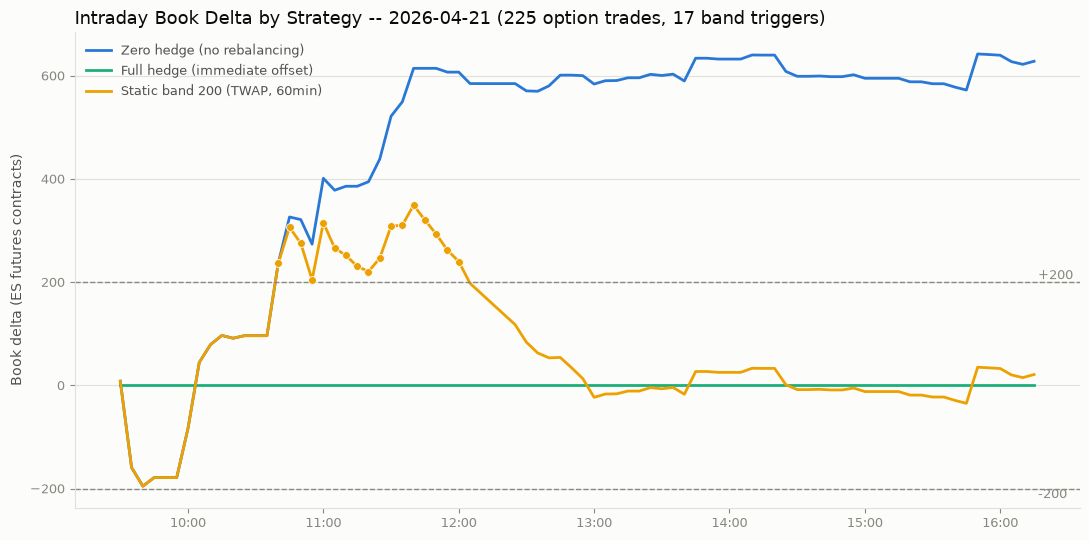

Wrote figure to outputs\figures\intraday_delta_path_by_strategy.png


In [13]:
ILLUSTRATIVE_BAND = 200
ILLUSTRATIVE_METHOD = 'twap'
ILLUSTRATIVE_HORIZON = 60
MIN_TRIGGERS_FOR_SAMPLE_DAY = 2

# Pick the trading day where the illustrative band diverges most from zero
# hedge in cumulative delta PnL, so the chart shows both a real trigger ->
# unwind -> re-accumulation cycle and a visible economic difference between
# the two strategies (rather than just the busiest day by trade count).
candidate_days = []
for trade_date, day_grid in bar_grid.groupby('trade_date'):
    day_grid = day_grid.sort_values('bar_time').reset_index(drop=True)
    day_zero_delta = day_grid['option_delta_arrival'].cumsum().to_numpy()
    day_static_path, day_triggers = simulate_static_band_day_path(day_grid, ILLUSTRATIVE_BAND, ILLUSTRATIVE_METHOD, ILLUSTRATIVE_HORIZON)
    if len(day_triggers) < MIN_TRIGGERS_FOR_SAMPLE_DAY:
        continue
    day_price = day_grid['es1_price'].to_numpy()
    day_zero_pnl = compute_delta_pnl(day_zero_delta, day_price)
    day_static_pnl = compute_delta_pnl(day_static_path['book_delta'].to_numpy(), day_price)
    candidate_days.append({
        'trade_date': trade_date,
        'n_option_trades': int(day_grid['n_option_trades'].sum()),
        'n_triggers': len(day_triggers),
        'max_pnl_gap': np.max(np.abs(day_zero_pnl - day_static_pnl)),
    })

candidate_days_df = pd.DataFrame(candidate_days)
sample_day = candidate_days_df.sort_values('max_pnl_gap', ascending=False)['trade_date'].iloc[0]

day_grid_sample = (
    bar_grid.loc[bar_grid['trade_date'].eq(sample_day)]
    .sort_values('bar_time')
    .reset_index(drop=True)
)

zero_hedge_delta = day_grid_sample['option_delta_arrival'].cumsum().to_numpy()
full_hedge_delta = np.zeros(len(day_grid_sample))

static_band_path, static_band_triggers = simulate_static_band_day_path(
    day_grid_sample, ILLUSTRATIVE_BAND, ILLUSTRATIVE_METHOD, ILLUSTRATIVE_HORIZON
)

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(day_grid_sample['bar_time'], zero_hedge_delta, color=COLOR_ZERO_HEDGE, linewidth=2, label='Zero hedge (no rebalancing)')
ax.plot(day_grid_sample['bar_time'], full_hedge_delta, color=COLOR_FULL_HEDGE, linewidth=2, label='Full hedge (immediate offset)')
ax.plot(
    static_band_path['bar_time'], static_band_path['book_delta'], color=COLOR_STATIC_BAND, linewidth=2,
    label=f'Static band {ILLUSTRATIVE_BAND:,.0f} ({ILLUSTRATIVE_METHOD.upper()}, {ILLUSTRATIVE_HORIZON}min)',
)
if not static_band_triggers.empty:
    ax.scatter(
        static_band_triggers['bar_time'], static_band_triggers['book_delta'], color=COLOR_STATIC_BAND, s=32,
        zorder=5, edgecolor=SURFACE, linewidth=0.6,
    )

ax.axhline(ILLUSTRATIVE_BAND, color=INK_MUTED, linestyle='--', linewidth=1)
ax.axhline(-ILLUSTRATIVE_BAND, color=INK_MUTED, linestyle='--', linewidth=1)
ax.text(day_grid_sample['bar_time'].iloc[-1], ILLUSTRATIVE_BAND, f' +{ILLUSTRATIVE_BAND:,.0f}', color=INK_MUTED, fontsize=9, va='bottom')
ax.text(day_grid_sample['bar_time'].iloc[-1], -ILLUSTRATIVE_BAND, f' -{ILLUSTRATIVE_BAND:,.0f}', color=INK_MUTED, fontsize=9, va='top')

n_trades_sample = int(day_grid_sample['n_option_trades'].sum())
ax.set_title(
    f'Intraday Book Delta by Strategy -- {sample_day.date()} ({n_trades_sample:,} option trades, {len(static_band_triggers)} band triggers)',
    color=INK_PRIMARY, fontsize=13, loc='left',
)
ax.set_ylabel('Book delta (ES futures contracts)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(loc='upper left', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()

fig_path = OUTPUT_FIGURE_DIR / 'intraday_delta_path_by_strategy.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')

## 12. Delta PnL: The Cost of Carrying Unhedged Exposure

Book delta by itself only shows exposure; it doesn't show what that exposure costs or earns as the underlying moves. This section converts each strategy's book-delta path from Section 11 into a cumulative delta PnL: the mark-to-market gain or loss from carrying the prior bar's book delta through the next price move, `pnl_bar = book_delta[t-1] * (es1_price[t] - es1_price[t-1]) * $50`, cumulated across the day (book delta is in ES contracts, so the $50-per-point multiplier converts point PnL to dollars). Full hedge stays flat at zero PnL by construction (it never carries delta between bars); zero hedge and the static band show how much directional P&L swings the book absorbs by not being immediately flat.

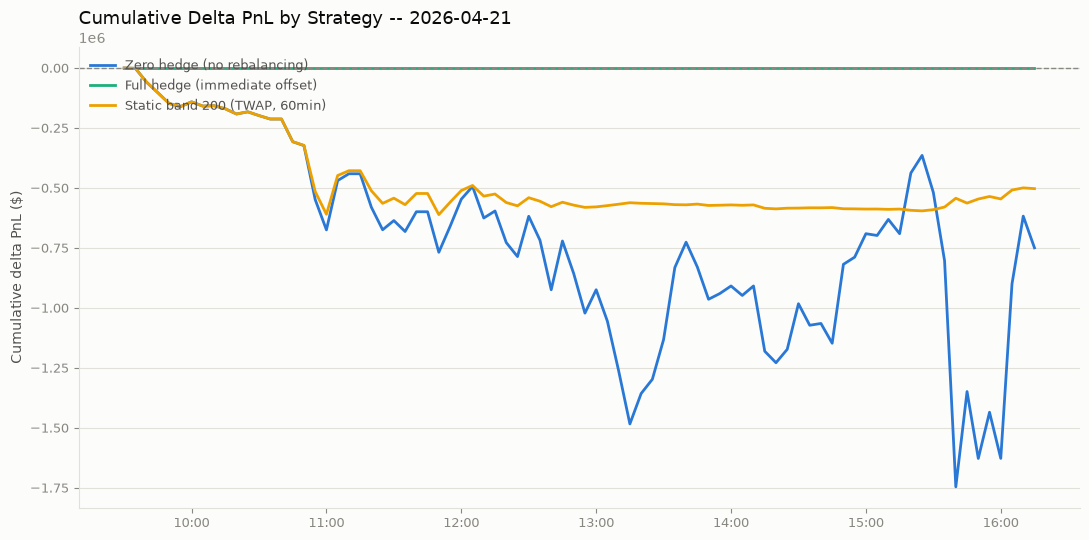

Wrote figure to outputs\figures\intraday_delta_pnl_by_strategy.png
End-of-day delta PnL -- zero hedge: -749,651, full hedge: 0, static band: -502,864


In [14]:
price_sample = day_grid_sample['es1_price'].to_numpy()

zero_hedge_pnl = compute_delta_pnl(zero_hedge_delta, price_sample)
full_hedge_pnl = compute_delta_pnl(full_hedge_delta, price_sample)
static_band_pnl = compute_delta_pnl(static_band_path['book_delta'].to_numpy(), price_sample)

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(day_grid_sample['bar_time'], zero_hedge_pnl, color=COLOR_ZERO_HEDGE, linewidth=2, label='Zero hedge (no rebalancing)')
ax.plot(day_grid_sample['bar_time'], full_hedge_pnl, color=COLOR_FULL_HEDGE, linewidth=2, label='Full hedge (immediate offset)')
ax.plot(
    day_grid_sample['bar_time'], static_band_pnl, color=COLOR_STATIC_BAND, linewidth=2,
    label=f'Static band {ILLUSTRATIVE_BAND:,.0f} ({ILLUSTRATIVE_METHOD.upper()}, {ILLUSTRATIVE_HORIZON}min)',
)
ax.axhline(0, color=INK_MUTED, linestyle='--', linewidth=1)

ax.set_title(f'Cumulative Delta PnL by Strategy -- {sample_day.date()}', color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_ylabel('Cumulative delta PnL ($)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(loc='upper left', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()

pnl_fig_path = OUTPUT_FIGURE_DIR / 'intraday_delta_pnl_by_strategy.png'
fig.savefig(pnl_fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {pnl_fig_path.relative_to(PROJECT_ROOT)}')
print(f'End-of-day delta PnL -- zero hedge: {zero_hedge_pnl[-1]:,.0f}, full hedge: {full_hedge_pnl[-1]:,.0f}, static band: {static_band_pnl[-1]:,.0f}')

## 13. Trade-by-Trade PnL Attribution

Sections 11-12 show the *aggregate* book-delta and PnL path for the sample day. This section breaks that same day down to the individual option trade: for every executed call/put, what level was the underlying at on arrival, what level was it hedged at, and what that specific trade contributed to the day's hedging PnL.

Hedges are not FIFO against individual trades by construction -- a static-band trigger offsets whatever the *net* book delta happens to be at that moment. So each option trade's exposure is matched against the realized hedge fills **FIFO, in time order** (oldest exposure closed first), including matching directly against a later *opposite-side* option trade when one arrives before any rebalance fires. Zero hedge is the same construction with the band set to infinity, so every trade's only closing event is the end-of-day mark.

PnL from carrying a position is linear in its build-up, so crediting each closed unit of delta to the trade it came from and summing reproduces the aggregate cumulative delta PnL from Section 12, up to two small, explicitly tracked residuals (reconciled below). First, a TWAP/VWAP schedule, once started, is blind to what arrives afterward, so a fill can occasionally land on the *same* side as the position already open (extending it rather than closing it) instead of the opposite side the strategy intended. Whatever PnL that fill later generates isn't really attributable to a specific option trade, so it's tracked separately as an **unattributed residual** rather than forced onto whichever trade happens to be next in the queue. Second, ES futures hedge in whole contracts, so a sub-contract sliver of exposure can remain open at the end-of-day flatten; its mark-to-market drift stays in the aggregate path but has no closing event to attribute.

In [15]:
from collections import defaultdict, deque


def simulate_static_band_day_with_fills(day_grid: pd.DataFrame, band: float, method: str, horizon_minutes: int) -> pd.DataFrame:
    """Replay the static-band simulator (whole-contract fills with a fractional carry,
    matching notebook 02), logging every hedge fill (bar, price, qty, and which
    rebalance it belongs to).

    Setting band=np.inf reproduces zero hedge: the band is never breached, so the only fill
    logged is the end-of-day flatten (rebalance_seq -1) -- the single-cohort construction zero
    hedge needs.
    """
    book_delta = 0.0
    active_schedule = pd.DataFrame(columns=['idx', 'hedge_delta'])
    pending_hedge = 0.0
    day_grid = day_grid.reset_index(drop=True).copy()
    fills = []
    n_triggers = 0

    for i, row in day_grid.iterrows():
        book_delta += float(row.option_delta_arrival)

        scheduled = active_schedule.loc[active_schedule['idx'].eq(i), 'hedge_delta']
        pending_hedge += float(scheduled.sum()) if not scheduled.empty else 0.0
        hedge_contracts = int(round(pending_hedge))
        if hedge_contracts != 0:
            pending_hedge -= hedge_contracts
            book_delta += hedge_contracts
            fills.append({
                'bar_idx': i, 'bar_time': row.bar_time, 'price': row.es1_price, 'fill_qty': hedge_contracts,
                'rebalance_seq': n_triggers - 1,
            })

        if abs(book_delta) > band:
            n_triggers += 1
            parent_order = -book_delta
            pending_hedge = 0.0
            active_schedule = make_child_schedule(parent_order, i + 1, day_grid, horizon_minutes, method)

    last_row = day_grid.iloc[-1]
    close_contracts = -int(round(book_delta))
    if close_contracts != 0:
        fills.append({
            'bar_idx': len(day_grid) - 1, 'bar_time': last_row.bar_time, 'price': last_row.es1_price,
            'fill_qty': close_contracts, 'rebalance_seq': -1,
        })

    return pd.DataFrame(fills)


def fifo_hedge_attribution(trades: pd.DataFrame, fills: pd.DataFrame) -> tuple[pd.DataFrame, dict, float]:
    """FIFO-match each option trade's signed delta against the realized hedge fills (in time
    order, opposite sign only) to attribute exact hedging PnL to each trade, and record the
    individual closing legs that make up each trade's hedge -- either a genuine ES futures
    execution from a specific rebalance, or a later offsetting option trade netting against it
    before any rebalance was needed. Quantities are ES contracts; PnL is converted to dollars
    via the $50-per-point multiplier.

    PnL from carrying a position is linear in its build-up, so crediting each closed unit of
    delta to the trade it came from and summing reproduces the aggregate cumulative delta PnL,
    up to two residuals reported alongside: (1) a TWAP/VWAP schedule is blind to what arrives
    after it starts, so a fill can occasionally land on the same side as the position that's
    already open (extending it rather than closing it) -- any PnL such a fill later generates
    isn't tied to a specific option trade, so it is returned separately as an unattributed
    residual; (2) hedges trade in whole contracts, so a sub-contract sliver of exposure can
    stay open (unmatched) at the end of the day.

    Returns (summary, legs, fill_absorptions, unattributed_pnl). fill_absorptions is the
    flip side of residual (1): per arriving trade, the delta units that were closed on
    arrival by an earlier same-side fill's excess contracts -- those units are hedged
    (instantly), but their closing leg is an ES lot no specific rebalance intent owns.
    """
    events = (
        [{'bar_idx': r.bar_idx, 'bar_time': r.bar_time, 'is_fill': False, 'trade_id': r.trade_id, 'qty': r.qty, 'price': r.price, 'rebalance_seq': None} for r in trades.itertuples()]
        + [{'bar_idx': r.bar_idx, 'bar_time': r.bar_time, 'is_fill': True, 'trade_id': None, 'qty': r.fill_qty, 'price': r.price, 'rebalance_seq': r.rebalance_seq} for r in fills.itertuples()]
    )
    events.sort(key=lambda e: (e['bar_idx'], e['is_fill']))

    queue: deque = deque()  # each entry: dict(trade_id_or_None, qty, price, bar_time)
    pnl = defaultdict(float)
    matched_abs = defaultdict(float)
    matched_notional = defaultdict(float)
    matched_via_fill_abs = defaultdict(float)
    matched_minutes_weighted = defaultdict(float)
    legs = defaultdict(list)
    fill_absorptions = defaultdict(list)
    unattributed_pnl = 0.0

    for e in events:
        remaining = e['qty']
        while abs(remaining) > 1e-9 and queue and np.sign(queue[0]['qty']) == -np.sign(remaining):
            lot = queue[0]
            m = min(abs(lot['qty']), abs(remaining))
            signed_close = np.sign(lot['qty']) * m
            contribution = signed_close * (e['price'] - lot['price']) * ES_MULTIPLIER
            if lot['trade_id'] is not None:
                tid = lot['trade_id']
                pnl[tid] += contribution
                matched_abs[tid] += m
                matched_notional[tid] += m * e['price']
                matched_minutes_weighted[tid] += m * (e['bar_time'] - lot['bar_time']).total_seconds() / 60
                if e['is_fill']:
                    matched_via_fill_abs[tid] += m
                    legs[tid].append({
                        'closing_type': 'ES execution',
                        'matched_qty': m,
                        'es_signed_qty': -signed_close,
                        'hedge_price': e['price'],
                        'hedge_bar_time': e['bar_time'],
                        'rebalance_seq': e['rebalance_seq'],
                    })
                else:
                    legs[tid].append({
                        'closing_type': 'offsetting option trade',
                        'matched_qty': m,
                        'hedge_price': e['price'],
                        'hedge_bar_time': e['bar_time'],
                        'closing_trade_id': e['trade_id'],
                    })
            else:
                unattributed_pnl += contribution
                if not e['is_fill']:
                    fill_absorptions[e['trade_id']].append({
                        'matched_qty': m,
                        'fill_bar_time': lot['bar_time'],
                        'fill_price': lot['price'],
                    })
            lot['qty'] -= np.sign(lot['qty']) * m
            remaining -= np.sign(remaining) * m
            if abs(lot['qty']) <= 1e-9:
                queue.popleft()
        if abs(remaining) > 1e-9:
            queue.append({'trade_id': e['trade_id'], 'qty': remaining, 'price': e['price'], 'bar_time': e['bar_time']})

    summary = pd.DataFrame({'trade_id': list(pnl.keys())})
    summary['hedging_pnl'] = summary['trade_id'].map(pnl)
    summary['matched_abs_qty'] = summary['trade_id'].map(matched_abs)
    summary['weighted_avg_hedge_price'] = summary['trade_id'].map(matched_notional) / summary['matched_abs_qty']
    summary['minutes_to_hedge'] = summary['trade_id'].map(matched_minutes_weighted) / summary['matched_abs_qty']
    summary['pct_closed_by_rebalance'] = summary['trade_id'].map(matched_via_fill_abs).fillna(0.0) / summary['matched_abs_qty'] * 100
    return summary, legs, fill_absorptions, unattributed_pnl

In [16]:
bar_index_lookup = day_grid_sample[['bar_time']].reset_index().rename(columns={'index': 'bar_idx'})

sample_trades = (
    delta_arrivals.loc[delta_arrivals['bar_time'].dt.normalize().eq(sample_day)]
    .merge(bar_index_lookup, on='bar_time', how='left')
    .sort_values('timestamp_et')
    .reset_index(drop=True)
)

trades_for_match = pd.DataFrame({
    'trade_id': sample_trades['trade_id'],
    'bar_idx': sample_trades['bar_idx'],
    'bar_time': sample_trades['bar_time'],
    'qty': sample_trades['signed_delta_contracts'],
    'price': sample_trades['es1_price'],
})

static_fills = simulate_static_band_day_with_fills(day_grid_sample, ILLUSTRATIVE_BAND, ILLUSTRATIVE_METHOD, ILLUSTRATIVE_HORIZON)
zero_fills = simulate_static_band_day_with_fills(day_grid_sample, np.inf, ILLUSTRATIVE_METHOD, ILLUSTRATIVE_HORIZON)

static_attr, static_legs, static_fill_absorptions, static_unattributed = fifo_hedge_attribution(trades_for_match, static_fills)
zero_attr, zero_legs, zero_fill_absorptions, zero_unattributed = fifo_hedge_attribution(trades_for_match, zero_fills)

static_attr = static_attr.rename(columns={c: f'static_{c}' for c in static_attr.columns if c != 'trade_id'})
zero_attr = zero_attr.rename(columns={c: f'zero_{c}' for c in zero_attr.columns if c != 'trade_id'})

sample_trades = sample_trades.merge(static_attr, on='trade_id', how='left').merge(zero_attr, on='trade_id', how='left')

# A trade that arrives and is used entirely to close out an OLDER trade's exposure (rather
# than ever becoming an open lot itself) gets no entry from fifo_hedge_attribution -- its
# economics are already fully embedded in whichever earlier trade(s) it closed out. Recorded
# here as a zero-pnl, instant hedge at its own arrival price rather than left as missing data.
for col in ['static_hedging_pnl', 'zero_hedging_pnl', 'static_pct_closed_by_rebalance', 'static_minutes_to_hedge']:
    sample_trades[col] = sample_trades[col].fillna(0.0)
sample_trades['static_weighted_avg_hedge_price'] = sample_trades['static_weighted_avg_hedge_price'].fillna(sample_trades['es1_price'])
sample_trades['zero_weighted_avg_hedge_price'] = sample_trades['zero_weighted_avg_hedge_price'].fillna(sample_trades['es1_price'])

sample_trades['pnl_advantage_static_vs_zero'] = sample_trades['static_hedging_pnl'] - sample_trades['zero_hedging_pnl']
sample_trades['pct_strike_from_spot'] = (sample_trades['strike'] - sample_trades['es1_price']) / sample_trades['es1_price'] * 100

trade_level_pnl = sample_trades[[
    'trade_id', 'timestamp_et', 'opt_type', 'strike', 'side', 'quantity', 'es1_price', 'pct_strike_from_spot',
    'delta', 'signed_delta_contracts', 'signed_delta_notional',
    'zero_weighted_avg_hedge_price', 'zero_hedging_pnl',
    'static_weighted_avg_hedge_price', 'static_pct_closed_by_rebalance', 'static_minutes_to_hedge', 'static_hedging_pnl',
    'pnl_advantage_static_vs_zero',
]].rename(columns={
    'es1_price': 'arrival_es1_price',
    'zero_weighted_avg_hedge_price': 'zero_hedge_price',
    'static_weighted_avg_hedge_price': 'static_hedge_price',
}).sort_values('timestamp_et').reset_index(drop=True)

table_path = OUTPUT_TABLE_DIR / 'sample_day_trade_level_pnl.csv'
trade_level_pnl.to_csv(table_path, index=False)

recon_zero = trade_level_pnl['zero_hedging_pnl'].sum() + zero_unattributed
recon_static = trade_level_pnl['static_hedging_pnl'].sum() + static_unattributed
win_rate = (trade_level_pnl['pnl_advantage_static_vs_zero'] > 0).mean() * 100

print(f'Sample day: {sample_day.date()}  ({len(trade_level_pnl):,} option trades, {len(static_band_triggers)} static-band triggers)')
print(f'Wrote trade-level table to {table_path.relative_to(PROJECT_ROOT)}')
print()
print('Reconciliation vs. Section 12 aggregate cumulative delta PnL:')
print(f'  Zero hedge:   trade-attributed = {trade_level_pnl["zero_hedging_pnl"].sum():>13,.0f}   unattributed = {zero_unattributed:>10,.0f}   total = {recon_zero:>13,.0f}   vs. aggregate = {zero_hedge_pnl[-1]:>13,.0f}')
print(f'  Static band:  trade-attributed = {trade_level_pnl["static_hedging_pnl"].sum():>13,.0f}   unattributed = {static_unattributed:>10,.0f}   total = {recon_static:>13,.0f}   vs. aggregate = {static_band_pnl[-1]:>13,.0f}')
print()
print(f'Static band beats zero hedge on {win_rate:.1f}% of trades on this day (by per-trade hedging PnL).')
print()
trade_level_pnl.head(20)

Sample day: 2026-04-21  (225 option trades, 17 static-band triggers)
Wrote trade-level table to outputs\tables\sample_day_trade_level_pnl.csv

Reconciliation vs. Section 12 aggregate cumulative delta PnL:
  Zero hedge:   trade-attributed =      -749,651   unattributed =          0   total =      -749,651   vs. aggregate =      -749,651
  Static band:  trade-attributed =      -512,716   unattributed =      9,852   total =      -502,864   vs. aggregate =      -502,864

Static band beats zero hedge on 24.4% of trades on this day (by per-trade hedging PnL).



,trade_id,timestamp_et,opt_type,strike,side,quantity,arrival_es1_price,pct_strike_from_spot,delta,signed_delta_contracts,signed_delta_notional,zero_hedge_price,zero_hedging_pnl,static_hedge_price,static_pct_closed_by_rebalance,static_minutes_to_hedge,static_hedging_pnl,pnl_advantage_static_vs_zero
0,24738,2026-04-21 09:31:56,C,8000.0,BUY,2,7153.25,11.837277,0.322243,0.644486,2.305084e+05,7153.250000,0.000000,7153.250000,0.0,0.000000,0.000000,0.0
1,24739,2026-04-21 09:34:03,P,6800.0,SELL,72,7153.25,-4.938315,-0.216389,15.579984,5.572376e+06,7151.440211,-1409.824583,7151.440211,0.0,2.585414,-1409.824583,0.0
2,24740,2026-04-21 09:34:29,C,7350.0,SELL,23,7153.25,2.750498,0.355145,-8.168330,-2.921505e+06,7153.250000,0.000000,7153.250000,0.0,0.000000,0.000000,0.0
3,24741,2026-04-21 09:35:26,C,7350.0,SELL,119,7149.75,2.800797,0.352474,-41.944376,-1.499459e+07,7152.383430,-4462.114711,7152.383430,0.0,2.241217,-4462.114711,0.0
4,24742,2026-04-21 09:35:57,C,8000.0,BUY,5,7149.75,11.892024,0.052142,0.260709,9.320013e+04,7149.750000,0.000000,7149.750000,0.0,0.000000,0.000000,0.0
5,24743,2026-04-21 09:36:03,C,7350.0,SELL,15,7149.75,2.800797,0.352474,-5.287106,-1.890074e+06,7161.500000,-3106.174879,7161.500000,0.0,10.000000,-3106.174879,0.0
6,24744,2026-04-21 09:36:41,C,7100.0,SELL,1,7149.75,-0.695829,0.551148,-0.551148,-1.970284e+05,7161.500000,-323.799173,7161.500000,0.0,10.000000,-323.799173,0.0
7,24745,2026-04-21 09:36:43,C,8050.0,BUY,4,7149.75,12.591349,0.146556,0.586223,2.095673e+05,7149.750000,0.000000,7149.750000,0.0,0.000000,0.000000,0.0
8,24746,2026-04-21 09:37:29,C,7350.0,SELL,379,7149.75,2.800797,0.352474,-133.587549,-4.775588e+07,7166.068503,-108997.439471,7166.068503,0.0,25.131062,-108997.439471,0.0
9,24747,2026-04-21 09:37:33,P,6475.0,BUY,1,7149.75,-9.437393,-0.067136,-0.067136,-2.400012e+04,7170.000000,-67.974731,7170.000000,0.0,30.000000,-67.974731,0.0


### Hedge Mechanism Detail: 10 Illustrative Trades

The table above nets each trade down to a single hedge price and PnL, but that hedge is not always one clean event -- a trade's exposure can be closed in several separate legs. Each leg below is one of two things:

- **an ES execution** -- an actual futures trade ticket from a triggered rebalance (its own timestamp, price, and quantity), or the end-of-day flatten; or
- **an offsetting option trade** -- a later option trade on the opposite side that happened to net against this one before any rebalance was ever needed.

The 10 trades below (under the static-band strategy) are split evenly: 5 of the largest trades hedged entirely by ES execution, and 5 of the largest trades hedged entirely by offsetting option flow. A trade can appear with more than one leg row if its exposure was closed in pieces.

One more wrinkle worth surfacing rather than hiding: a large trade can *also* arrive on the opposite side of an already-open position and immediately close part of it out -- that portion's PnL is credited to the *earlier* trade it closed, not to this one, so it never shows up as a leg of this trade at all. The summary table below the legs makes that split explicit: `qty_closed_by_legs_shown` (what actually became this trade's own tracked position, shown in the legs table) vs. `qty_used_to_close_earlier_exposure` (the part of this trade that immediately flattened someone else's still-open position on arrival).

In [17]:
N_ILLUSTRATIVE_EACH = 5

trade_info = sample_trades.set_index('trade_id')[
    ['timestamp_et', 'opt_type', 'strike', 'side', 'quantity', 'signed_delta_contracts', 'signed_delta_notional']
]

es_hedged_ids = (
    sample_trades.loc[sample_trades['static_pct_closed_by_rebalance'].ge(99.9)]
    .assign(abs_notional=lambda d: d['signed_delta_notional'].abs())
    .nlargest(N_ILLUSTRATIVE_EACH, 'abs_notional')['trade_id']
    .tolist()
)
option_netted_ids = (
    sample_trades.loc[sample_trades['static_pct_closed_by_rebalance'].le(0.1) & sample_trades['static_hedging_pnl'].ne(0.0)]
    .assign(abs_notional=lambda d: d['signed_delta_notional'].abs())
    .nlargest(N_ILLUSTRATIVE_EACH, 'abs_notional')['trade_id']
    .tolist()
)
illustrative_trade_ids = es_hedged_ids + option_netted_ids

leg_rows = []
summary_rows = []
for tid in illustrative_trade_ids:
    info = trade_info.loc[tid]
    trade_legs = static_legs.get(tid, [])
    for leg_seq, leg in enumerate(trade_legs, start=1):
        row = {
            'trade_id': tid,
            'arrival_time': info['timestamp_et'],
            'opt_type': info['opt_type'],
            'strike': info['strike'],
            'option_side': info['side'],
            'quantity': info['quantity'],
            'signed_delta_contracts': round(info['signed_delta_contracts'], 1),
            'leg': leg_seq,
            'closing_type': leg['closing_type'],
            'matched_qty': round(leg['matched_qty'], 1),
            'hedge_price': leg['hedge_price'],
            'hedge_bar_time': leg['hedge_bar_time'],
        }
        if leg['closing_type'] == 'ES execution':
            fill_row = static_fills.loc[
                static_fills['bar_time'].eq(leg['hedge_bar_time']) & static_fills['rebalance_seq'].eq(leg['rebalance_seq'])
            ].iloc[0]
            row['rebalance'] = 'EOD flatten' if leg['rebalance_seq'] == -1 else f"Rebalance {leg['rebalance_seq'] + 1}"
            row['es_side'] = 'BUY' if leg['es_signed_qty'] > 0 else 'SELL'
            row['es_trade_qty_total'] = round(abs(fill_row['fill_qty']), 1)
            row['closing_option_trade'] = None
        else:
            closer = trade_info.loc[leg['closing_trade_id']]
            row['rebalance'] = None
            row['es_side'] = None
            row['es_trade_qty_total'] = None
            row['closing_option_trade'] = f"#{leg['closing_trade_id']} ({closer['opt_type']} {closer['strike']:,.0f} {closer['side']})"
        leg_rows.append(row)

    qty_closed_by_legs_shown = sum(leg['matched_qty'] for leg in trade_legs)
    summary_rows.append({
        'trade_id': tid,
        'opt_type': info['opt_type'],
        'strike': info['strike'],
        'option_side': info['side'],
        'abs_delta_contracts': round(abs(info['signed_delta_contracts']), 1),
        'qty_closed_by_legs_shown': round(qty_closed_by_legs_shown, 1),
        'qty_used_to_close_earlier_exposure': round(abs(info['signed_delta_contracts']) - qty_closed_by_legs_shown, 1),
    })

hedge_mechanism_detail = pd.DataFrame(leg_rows)
hedge_mechanism_summary = pd.DataFrame(summary_rows)

detail_path = OUTPUT_TABLE_DIR / 'sample_day_hedge_mechanism_detail.csv'
hedge_mechanism_detail.to_csv(detail_path, index=False)

print(f'Wrote hedge-mechanism detail to {detail_path.relative_to(PROJECT_ROOT)}')
print(f'{len(illustrative_trade_ids)} trades ({len(es_hedged_ids)} ES-hedged, {len(option_netted_ids)} option-netted), {len(hedge_mechanism_detail)} closing legs total')
print()
print('Per-trade split: how much of each trade became its own tracked position (closed by the legs below) vs. was used immediately to close an earlier trade:')
display(hedge_mechanism_summary)
print()
hedge_mechanism_detail

Wrote hedge-mechanism detail to outputs\tables\sample_day_hedge_mechanism_detail.csv
10 trades (5 ES-hedged, 5 option-netted), 35 closing legs total

Per-trade split: how much of each trade became its own tracked position (closed by the legs below) vs. was used immediately to close an earlier trade:


,trade_id,opt_type,strike,option_side,abs_delta_contracts,qty_closed_by_legs_shown,qty_used_to_close_earlier_exposure
0,24863,C,7500.0,BUY,15.7,15.7,0.0
1,24883,C,7350.0,BUY,11.5,11.5,0.0
2,24873,C,7350.0,BUY,8.1,8.1,0.0
3,24845,P,6800.0,SELL,7.7,7.7,0.0
4,24841,C,7350.0,BUY,7.5,7.5,0.0
5,24746,C,7350.0,SELL,133.6,133.6,0.0
6,24741,C,7350.0,SELL,41.9,33.9,8.1
7,24920,C,7350.0,BUY,38.3,26.8,11.6
8,24940,C,7350.0,SELL,36.5,36.5,0.0
9,24913,C,7350.0,SELL,21.7,17.3,4.4


,trade_id,arrival_time,opt_type,strike,option_side,quantity,signed_delta_contracts,leg,closing_type,matched_qty,hedge_price,hedge_bar_time,rebalance,es_side,es_trade_qty_total,closing_option_trade
0,24863,2026-04-21 11:39:38,C,7500.0,BUY,67,15.7,1,ES execution,15.7,7128.50,2026-04-21 12:30:00,Rebalance 17,SELL,20.0,NaN
1,24883,2026-04-21 12:44:59,C,7350.0,BUY,35,11.5,1,ES execution,11.5,7114.75,2026-04-21 12:55:00,Rebalance 17,SELL,20.0,NaN
2,24873,2026-04-21 11:44:39,C,7350.0,BUY,24,8.1,1,ES execution,8.1,7120.25,2026-04-21 12:50:00,Rebalance 17,SELL,20.0,NaN
3,24845,2026-04-21 11:13:02,P,6800.0,SELL,34,7.7,1,ES execution,7.7,7131.00,2026-04-21 12:00:00,Rebalance 16,SELL,22.0,NaN
4,24841,2026-04-21 11:08:45,C,7350.0,BUY,22,7.5,1,ES execution,6.5,7127.25,2026-04-21 11:55:00,Rebalance 15,SELL,24.0,NaN
5,24841,2026-04-21 11:08:45,C,7350.0,BUY,22,7.5,2,ES execution,1.1,7131.00,2026-04-21 12:00:00,Rebalance 16,SELL,22.0,NaN
6,24746,2026-04-21 09:37:29,C,7350.0,SELL,379,-133.6,1,offsetting option trade,3.2,7161.50,2026-04-21 09:45:00,NaN,NaN,NaN,"#24759 (C 7,350 BUY)"
7,24746,2026-04-21 09:37:29,C,7350.0,SELL,379,-133.6,2,offsetting option trade,0.1,7166.50,2026-04-21 09:50:00,NaN,NaN,NaN,"#24760 (C 8,000 BUY)"
8,24746,2026-04-21 09:37:29,C,7350.0,SELL,379,-133.6,3,offsetting option trade,0.1,7165.75,2026-04-21 10:00:00,NaN,NaN,NaN,"#24761 (C 7,750 BUY)"
9,24746,2026-04-21 09:37:29,C,7350.0,SELL,379,-133.6,4,offsetting option trade,47.4,7165.75,2026-04-21 10:00:00,NaN,NaN,NaN,"#24762 (C 7,350 BUY)"


### Full Hedge Execution Log: Every Trade on the Sample Day

The 10-trade table above illustrates the mechanism; this cell builds the complete blotter-style log for **every** option trade on the sample day under the static-band strategy -- one row per closing leg, answering for each trade: when was it received (exact trade timestamp), when was each unit of its delta hedged, and by what:

- **ES execution (rebalance N / EOD flatten)** -- a real ES futures ticket. The leg shows the fill time, BUY/SELL side, the portion of the ticket allocated to this trade (`hedged_qty_contracts`), and the full ticket size (`es_ticket_qty` -- one rebalance fill closes whatever net exposure is open, so a ticket is shared FIFO across several trades).
- **offsetting option trade** -- no ES was traded. A later opposite-side option trade netted against this one before any rebalance was needed; the leg names that trade and its receive time.
- **netted on arrival ...** -- this trade itself arrived opposite already-open exposure and was hedged the instant it was received: either against an earlier option trade's open position, or against excess ES contracts a prior rebalance fill had already traded (the same-side-fill residual from the section intro, now attributed per trade via `fill_absorptions`).

Timing note: option receive times are exact trade timestamps, and hedges by option flow are stamped with the closing trade's exact receive time. The simulator executes ES fills at each bar's closing price and models nothing finer inside the bar, so ES legs are stamped at the bar **close** (label + 5 min). `minutes_to_hedge` is the exact difference and is never negative. The per-trade rollup nets each trade to one row -- first/last hedge time and how its delta was split across the three mechanisms -- plus any sub-contract sliver left unhedged at the EOD flatten.


In [18]:
# Full hedge execution log for every option trade on the sample day under the
# static-band strategy: exact receive time, when and how each unit of its delta
# was closed, the ES contracts traded to do it, and -- where no ES trade was
# needed -- which later option trade provided the offset instead.
#
# Timestamps: option events carry their exact trade time; ES fills execute at
# their bar's closing price, so they are stamped at the bar CLOSE (start + 5min)
# rather than the bar label, keeping every hedge_time >= the receive time.

trade_cols = sample_trades.set_index('trade_id')
received_ts = pd.to_datetime(trade_cols['timestamp_et'])
BAR_CLOSE_OFFSET = pd.Timedelta(minutes=BAR_MINUTES)


def describe_option_trade(tid) -> str:
    info = trade_cols.loc[tid]
    return f"#{tid} ({info['opt_type']} {info['strike']:,.0f} {info['side']} x{info['quantity']:.0f}, received {received_ts.loc[tid]:%H:%M:%S})"


log_rows = []

for r in sample_trades.itertuples():
    base = {
        'trade_id': r.trade_id,
        'option_received_time': received_ts.loc[r.trade_id],
        'opt_type': r.opt_type,
        'strike': r.strike,
        'option_side': r.side,
        'option_qty': r.quantity,
        'trade_delta_contracts': round(r.signed_delta_contracts, 2),
    }
    for leg in static_legs.get(r.trade_id, []):
        row = dict(base)
        row['hedged_qty_contracts'] = round(leg['matched_qty'], 2)
        row['hedge_price'] = leg['hedge_price']
        if leg['closing_type'] == 'ES execution':
            fill = static_fills.loc[
                static_fills['bar_time'].eq(leg['hedge_bar_time']) & static_fills['rebalance_seq'].eq(leg['rebalance_seq'])
            ].iloc[0]
            row['hedge_time'] = leg['hedge_bar_time'] + BAR_CLOSE_OFFSET
            row['hedged_via'] = 'ES execution (EOD flatten)' if leg['rebalance_seq'] == -1 else f"ES execution (rebalance {leg['rebalance_seq'] + 1})"
            row['es_side'] = 'BUY' if leg['es_signed_qty'] > 0 else 'SELL'
            row['es_ticket_qty'] = int(abs(fill['fill_qty']))
            row['closing_option_trade'] = None
        else:
            row['hedge_time'] = received_ts.loc[leg['closing_trade_id']]
            row['hedged_via'] = 'offsetting option trade'
            row['es_side'] = None
            row['es_ticket_qty'] = None
            row['closing_option_trade'] = describe_option_trade(leg['closing_trade_id'])
        log_rows.append(row)

# A trade can also arrive opposite an already-open position and have part (or all)
# of its delta absorbed the moment it is received. FIFO credits that PnL to the
# earlier trade, so those units live in static_legs under the EARLIER trade's id;
# invert them here so the arriving trade's own log shows those units as hedged
# instantly, on arrival, at its own price.
for earlier_tid, legs_list in static_legs.items():
    for leg in legs_list:
        if leg['closing_type'] != 'offsetting option trade':
            continue
        closer_tid = leg['closing_trade_id']
        c = trade_cols.loc[closer_tid]
        log_rows.append({
            'trade_id': closer_tid,
            'option_received_time': received_ts.loc[closer_tid],
            'opt_type': c['opt_type'],
            'strike': c['strike'],
            'option_side': c['side'],
            'option_qty': c['quantity'],
            'trade_delta_contracts': round(c['signed_delta_contracts'], 2),
            'hedged_qty_contracts': round(leg['matched_qty'], 2),
            'hedge_time': received_ts.loc[closer_tid],
            'hedge_price': leg['hedge_price'],
            'hedged_via': f'netted on arrival against earlier trade {describe_option_trade(earlier_tid)}',
            'es_side': None,
            'es_ticket_qty': None,
            'closing_option_trade': None,
        })

# Third mechanism: a trade can arrive opposite EXCESS ES contracts a prior rebalance
# fill had already traded (the same-side-fill residual described in the section intro).
# Those units are likewise hedged the moment the trade is received -- the ES contracts
# doing the hedging were simply executed before the option arrived.
for tid, absorptions in static_fill_absorptions.items():
    c = trade_cols.loc[tid]
    for a in absorptions:
        log_rows.append({
            'trade_id': tid,
            'option_received_time': received_ts.loc[tid],
            'opt_type': c['opt_type'],
            'strike': c['strike'],
            'option_side': c['side'],
            'option_qty': c['quantity'],
            'trade_delta_contracts': round(c['signed_delta_contracts'], 2),
            'hedged_qty_contracts': round(a['matched_qty'], 2),
            'hedge_time': received_ts.loc[tid],
            'hedge_price': c['es1_price'],
            'hedged_via': f"netted on arrival against ES contracts already traded (fill {a['fill_bar_time']:%H:%M} @ {a['fill_price']:,.2f})",
            'es_side': None,
            'es_ticket_qty': None,
            'closing_option_trade': None,
        })

hedge_execution_log = (
    pd.DataFrame(log_rows)
    .sort_values(['option_received_time', 'trade_id', 'hedge_time'])
    .reset_index(drop=True)
)
hedge_execution_log['minutes_to_hedge'] = (
    (hedge_execution_log['hedge_time'] - hedge_execution_log['option_received_time']).dt.total_seconds() / 60
).round(1)
hedge_execution_log['leg'] = hedge_execution_log.groupby('trade_id').cumcount() + 1
hedge_execution_log = hedge_execution_log[[
    'trade_id', 'option_received_time', 'opt_type', 'strike', 'option_side', 'option_qty',
    'trade_delta_contracts', 'leg', 'hedged_via', 'hedged_qty_contracts',
    'es_side', 'es_ticket_qty', 'closing_option_trade',
    'hedge_time', 'minutes_to_hedge', 'hedge_price',
]]

# One-row-per-trade rollup: when the trade was received, when its hedge started and
# finished, and how its delta was closed (fresh ES executions, offsetting option flow,
# or ES contracts a prior fill had already traded).
is_es_leg = hedge_execution_log['hedged_via'].str.startswith('ES execution')
is_prior_fill_leg = hedge_execution_log['hedged_via'].str.startswith('netted on arrival against ES contracts')
leg_agg = (
    hedge_execution_log
    .assign(
        es_qty=hedge_execution_log['hedged_qty_contracts'].where(is_es_leg, 0.0),
        prior_fill_qty=hedge_execution_log['hedged_qty_contracts'].where(is_prior_fill_leg, 0.0),
        option_netted_qty=hedge_execution_log['hedged_qty_contracts'].where(~is_es_leg & ~is_prior_fill_leg, 0.0),
    )
    .groupby('trade_id')
    .agg(
        n_hedge_legs=('leg', 'size'),
        first_hedge_time=('hedge_time', 'min'),
        fully_hedged_time=('hedge_time', 'max'),
        es_contracts_used=('es_qty', 'sum'),
        option_netted_contracts=('option_netted_qty', 'sum'),
        prior_es_fill_contracts=('prior_fill_qty', 'sum'),
    )
    .reset_index()
)

hedge_execution_summary = (
    sample_trades[['trade_id', 'timestamp_et', 'opt_type', 'strike', 'side', 'quantity', 'signed_delta_contracts']]
    .rename(columns={'timestamp_et': 'option_received_time', 'side': 'option_side', 'quantity': 'option_qty'})
    .merge(leg_agg, on='trade_id', how='left')
)
hedge_execution_summary['option_received_time'] = pd.to_datetime(hedge_execution_summary['option_received_time'])
hedge_execution_summary['n_hedge_legs'] = hedge_execution_summary['n_hedge_legs'].fillna(0).astype(int)
mech_cols = ['es_contracts_used', 'option_netted_contracts', 'prior_es_fill_contracts']
hedge_execution_summary[mech_cols] = hedge_execution_summary[mech_cols].fillna(0.0).round(2)
hedge_execution_summary['unhedged_at_eod'] = (
    hedge_execution_summary['signed_delta_contracts'].abs()
    - hedge_execution_summary[mech_cols].sum(axis=1)
).clip(lower=0).round(2)
hedge_execution_summary['minutes_to_fully_hedged'] = (
    (hedge_execution_summary['fully_hedged_time'] - hedge_execution_summary['option_received_time']).dt.total_seconds() / 60
).round(1)

log_path = OUTPUT_TABLE_DIR / 'sample_day_hedge_execution_log.csv'
summary_path = OUTPUT_TABLE_DIR / 'sample_day_hedge_execution_summary.csv'
hedge_execution_log.to_csv(log_path, index=False)
hedge_execution_summary.to_csv(summary_path, index=False)

hedged_qty_total = hedge_execution_log['hedged_qty_contracts'].sum()
es_share = hedge_execution_log.loc[is_es_leg, 'hedged_qty_contracts'].sum() / hedged_qty_total * 100
prior_fill_share = hedge_execution_log.loc[is_prior_fill_leg, 'hedged_qty_contracts'].sum() / hedged_qty_total * 100
option_share = 100 - es_share - prior_fill_share
es_hedged_trades = hedge_execution_summary.loc[hedge_execution_summary['es_contracts_used'].gt(0)]

print(f'Static-band hedge execution log for {sample_day.date()}: {len(hedge_execution_summary):,} option trades, {len(hedge_execution_log):,} closing legs')
print(f'Wrote leg-level log to {log_path.relative_to(PROJECT_ROOT)}')
print(f'Wrote per-trade summary to {summary_path.relative_to(PROJECT_ROOT)}')
print()
print(f'Of all hedged delta: {es_share:.1f}% closed by fresh ES executions, {option_share:.1f}% by offsetting option flow,')
print(f'{prior_fill_share:.1f}% absorbed on arrival by ES contracts a prior fill had already traded.')
print(f'For trades needing an ES execution, median time to fully hedged: {es_hedged_trades["minutes_to_fully_hedged"].median():.0f} min (max {es_hedged_trades["minutes_to_fully_hedged"].max():.0f} min).')
print(f'Delta left unhedged at the EOD flatten (whole-contract rounding): {hedge_execution_summary["unhedged_at_eod"].sum():.2f} contracts.')
print()
display(hedge_execution_log.head(25))
hedge_execution_summary.head(15)


Static-band hedge execution log for 2026-04-21: 225 option trades, 412 closing legs
Wrote leg-level log to outputs\tables\sample_day_hedge_execution_log.csv
Wrote per-trade summary to outputs\tables\sample_day_hedge_execution_summary.csv

Of all hedged delta: 28.8% closed by fresh ES executions, 70.2% by offsetting option flow,
0.9% absorbed on arrival by ES contracts a prior fill had already traded.
For trades needing an ES execution, median time to fully hedged: 45 min (max 72 min).
Delta left unhedged at the EOD flatten (whole-contract rounding): 0.11 contracts.



,trade_id,option_received_time,opt_type,strike,option_side,option_qty,trade_delta_contracts,leg,hedged_via,hedged_qty_contracts,es_side,es_ticket_qty,closing_option_trade,hedge_time,minutes_to_hedge,hedge_price
0,24738,2026-04-21 09:31:56,C,8000.0,BUY,2,0.64,1,offsetting option trade,0.64,NaN,NaN,"#24740 (C 7,350 SELL x23, received 09:34:29)",2026-04-21 09:34:29,2.6,7153.25
1,24739,2026-04-21 09:34:03,P,6800.0,SELL,72,15.58,1,offsetting option trade,7.52,NaN,NaN,"#24740 (C 7,350 SELL x23, received 09:34:29)",2026-04-21 09:34:29,0.4,7153.25
2,24739,2026-04-21 09:34:03,P,6800.0,SELL,72,15.58,2,offsetting option trade,8.06,NaN,NaN,"#24741 (C 7,350 SELL x119, received 09:35:26)",2026-04-21 09:35:26,1.4,7149.75
3,24740,2026-04-21 09:34:29,C,7350.0,SELL,23,-8.17,1,netted on arrival against earlier trade #24738...,0.64,NaN,NaN,NaN,2026-04-21 09:34:29,0.0,7153.25
4,24740,2026-04-21 09:34:29,C,7350.0,SELL,23,-8.17,2,netted on arrival against earlier trade #24739...,7.52,NaN,NaN,NaN,2026-04-21 09:34:29,0.0,7153.25
5,24741,2026-04-21 09:35:26,C,7350.0,SELL,119,-41.94,1,netted on arrival against earlier trade #24739...,8.06,NaN,NaN,NaN,2026-04-21 09:35:26,0.0,7149.75
6,24741,2026-04-21 09:35:26,C,7350.0,SELL,119,-41.94,2,offsetting option trade,0.26,NaN,NaN,"#24742 (C 8,000 BUY x5, received 09:35:57)",2026-04-21 09:35:57,0.5,7149.75
7,24741,2026-04-21 09:35:26,C,7350.0,SELL,119,-41.94,3,offsetting option trade,0.59,NaN,NaN,"#24745 (C 8,050 BUY x4, received 09:36:43)",2026-04-21 09:36:43,1.3,7149.75
8,24741,2026-04-21 09:35:26,C,7350.0,SELL,119,-41.94,4,offsetting option trade,8.81,NaN,NaN,"#24748 (C 7,350 BUY x25, received 09:38:00)",2026-04-21 09:38:00,2.6,7149.75
9,24741,2026-04-21 09:35:26,C,7350.0,SELL,119,-41.94,5,offsetting option trade,16.21,NaN,NaN,"#24750 (C 7,350 BUY x46, received 09:38:23)",2026-04-21 09:38:23,3.0,7149.75


,trade_id,option_received_time,opt_type,strike,option_side,option_qty,signed_delta_contracts,n_hedge_legs,first_hedge_time,fully_hedged_time,es_contracts_used,option_netted_contracts,prior_es_fill_contracts,unhedged_at_eod,minutes_to_fully_hedged
0,24738,2026-04-21 09:31:56,C,8000.0,BUY,2,0.644486,1,2026-04-21 09:34:29,2026-04-21 09:34:29,0.0,0.64,0.0,0.00,2.6
1,24739,2026-04-21 09:34:03,P,6800.0,SELL,72,15.579984,2,2026-04-21 09:34:29,2026-04-21 09:35:26,0.0,15.58,0.0,0.00,1.4
2,24740,2026-04-21 09:34:29,C,7350.0,SELL,23,-8.168330,2,2026-04-21 09:34:29,2026-04-21 09:34:29,0.0,8.16,0.0,0.01,0.0
3,24741,2026-04-21 09:35:26,C,7350.0,SELL,119,-41.944376,8,2026-04-21 09:35:26,2026-04-21 09:45:11,0.0,41.95,0.0,0.00,9.8
4,24742,2026-04-21 09:35:57,C,8000.0,BUY,5,0.260709,1,2026-04-21 09:35:57,2026-04-21 09:35:57,0.0,0.26,0.0,0.00,0.0
5,24743,2026-04-21 09:36:03,C,7350.0,SELL,15,-5.287106,1,2026-04-21 09:45:11,2026-04-21 09:45:11,0.0,5.29,0.0,0.00,9.1
6,24744,2026-04-21 09:36:41,C,7100.0,SELL,1,-0.551148,1,2026-04-21 09:45:11,2026-04-21 09:45:11,0.0,0.55,0.0,0.00,8.5
7,24745,2026-04-21 09:36:43,C,8050.0,BUY,4,0.586223,1,2026-04-21 09:36:43,2026-04-21 09:36:43,0.0,0.59,0.0,0.00,0.0
8,24746,2026-04-21 09:37:29,C,7350.0,SELL,379,-133.587549,13,2026-04-21 09:45:11,2026-04-21 10:06:30,0.0,133.58,0.0,0.01,29.0
9,24747,2026-04-21 09:37:33,P,6475.0,BUY,1,-0.067136,1,2026-04-21 10:06:30,2026-04-21 10:06:30,0.0,0.07,0.0,0.00,29.0


### Hedge Mechanism Mix Across Strategies

The log above is for the illustrative band of 200; this compares how the *same day's* gross option delta gets closed under different rebalancing intensities, using the same fills + FIFO attribution machinery. Two structural bounds frame the picture:

- **ES executions have a floor**: internal netting can only cancel flow that has an opposite side, so ES must always carry at least the day's net one-sided imbalance (|net| / gross, the dashed line's complement).
- **Option netting has a ceiling** (gross − |net|): the looser the strategy, the closer it gets to that ceiling. A band that never breaches intraday (1,000 here) is mechanically identical to zero hedge -- one EOD flatten ticket.

Tightening the band converts netting into ES churn: full hedge (band 0) trades ~2.4x the ES contracts of the band strategies for the same end-of-day flatness, and its early fills sit in the book as excess that later opposite-side option flow gets absorbed by (the green slice). That conversion is exactly the execution-cost side of the frontier in Section 4.


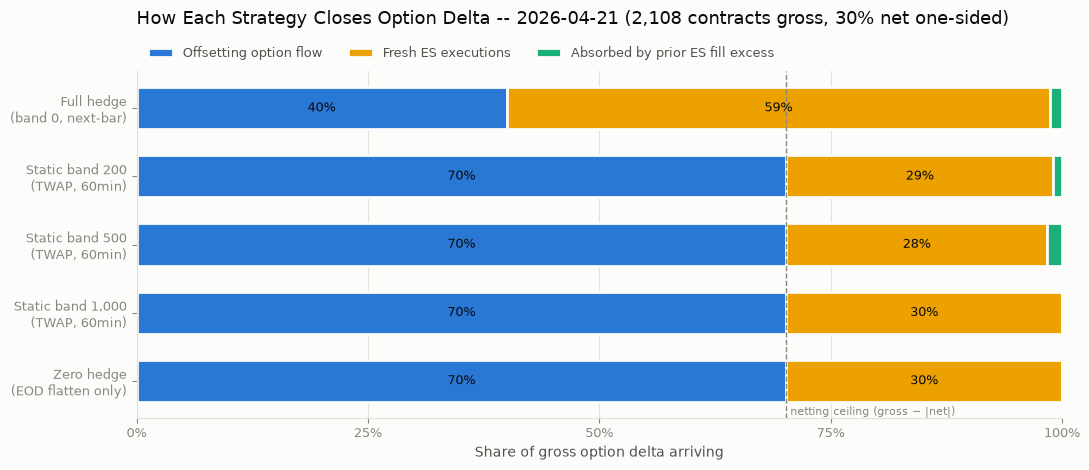

Wrote figure to outputs\figures\hedge_mechanism_mix_by_strategy.png
ES executions cannot go below the net one-sided imbalance: |net| / gross = 29.8% of the day's flow.



,option_pct,es_pct,absorbed_pct,es_contracts_traded,n_es_tickets
"Full hedge (band 0, next-bar)",40.0,58.8,1.3,1538,54
"Static band 200 (TWAP, 60min)",70.2,28.8,0.9,628,29
"Static band 500 (TWAP, 60min)",70.2,28.2,1.6,628,15
"Static band 1,000 (TWAP, 60min)",70.2,29.8,0.0,628,1
Zero hedge (EOD flatten only),70.2,29.8,0.0,628,1


In [19]:
# How does each strategy close the day's option delta? Sweep the same fills + FIFO
# attribution machinery across rebalancing aggressiveness on the sample day and split
# the gross arriving option delta by closing mechanism. Fresh ES executions can never
# fall below the day's net one-sided imbalance (internal netting only cancels flow
# that has an opposite side), and tighter strategies trade ES sooner, converting
# would-be option netting into ES fills plus reversals absorbed by their excess.


def mechanism_mix(band: float, method: str, horizon_minutes: int) -> dict:
    fills = simulate_static_band_day_with_fills(day_grid_sample, band, method, horizon_minutes)
    _, legs, absorptions, _ = fifo_hedge_attribution(trades_for_match, fills)
    es_qty = sum(l['matched_qty'] for lst in legs.values() for l in lst if l['closing_type'] == 'ES execution')
    # each option-vs-option match closes one unit of BOTH trades involved
    option_qty = 2 * sum(l['matched_qty'] for lst in legs.values() for l in lst if l['closing_type'] == 'offsetting option trade')
    absorbed_qty = sum(a['matched_qty'] for lst in absorptions.values() for a in lst)
    return {
        'option_pct': option_qty / gross_delta * 100,
        'es_pct': es_qty / gross_delta * 100,
        'absorbed_pct': absorbed_qty / gross_delta * 100,
        'es_contracts_traded': int(fills['fill_qty'].abs().sum()) if not fills.empty else 0,
        'n_es_tickets': len(fills),
    }


gross_delta = trades_for_match['qty'].abs().sum()
net_floor_pct = abs(trades_for_match['qty'].sum()) / gross_delta * 100

MIX_STRATEGIES = [
    ('Full hedge\n(band 0, next-bar)', 0.0, 'twap', 5),
    ('Static band 200\n(TWAP, 60min)', 200, 'twap', 60),
    ('Static band 500\n(TWAP, 60min)', 500, 'twap', 60),
    ('Static band 1,000\n(TWAP, 60min)', 1000, 'twap', 60),
    ('Zero hedge\n(EOD flatten only)', np.inf, 'twap', 60),
]

mix_rows = [mechanism_mix(band, method, horizon) for _, band, method, horizon in MIX_STRATEGIES]
mix_df = pd.DataFrame(mix_rows, index=[label.replace('\n', ' ') for label, *_ in MIX_STRATEGIES])

SEGMENTS = [
    ('Offsetting option flow', 'option_pct', COLOR_ZERO_HEDGE),
    ('Fresh ES executions', 'es_pct', COLOR_STATIC_BAND),
    ('Absorbed by prior ES fill excess', 'absorbed_pct', COLOR_FULL_HEDGE),
]

fig, ax = plt.subplots(figsize=(11, 4.8))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

y = np.arange(len(MIX_STRATEGIES))[::-1]  # first strategy on top
left = np.zeros(len(MIX_STRATEGIES))
for name, col, color in SEGMENTS:
    vals = mix_df[col].to_numpy()
    ax.barh(y, vals, left=left, height=0.62, color=color, edgecolor=SURFACE, linewidth=2, label=name)
    for yi, v, l0 in zip(y, vals, left):
        if v >= 4:
            ax.text(l0 + v / 2, yi, f'{v:.0f}%', ha='center', va='center', color=INK_PRIMARY, fontsize=9)
    left += vals

ax.set_yticks(y)
ax.set_yticklabels([label for label, *_ in MIX_STRATEGIES], fontsize=9, color=INK_SECONDARY)
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.set_xlabel('Share of gross option delta arriving', color=INK_SECONDARY, fontsize=10)

ax.axvline(100 - net_floor_pct, color=INK_MUTED, linestyle='--', linewidth=1)
ax.text(100 - net_floor_pct, ax.get_ylim()[0], ' netting ceiling (gross − |net|)', color=INK_MUTED, fontsize=8, va='bottom', ha='left')

ax.set_title(
    f'How Each Strategy Closes Option Delta -- {sample_day.date()} ({gross_delta:,.0f} contracts gross, {net_floor_pct:.0f}% net one-sided)',
    color=INK_PRIMARY, fontsize=13, loc='left', pad=34,
)
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), ncols=3, frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()

mix_fig_path = OUTPUT_FIGURE_DIR / 'hedge_mechanism_mix_by_strategy.png'
fig.savefig(mix_fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {mix_fig_path.relative_to(PROJECT_ROOT)}')
print(f'ES executions cannot go below the net one-sided imbalance: |net| / gross = {net_floor_pct:.1f}% of the day\'s flow.')
print()
mix_df.round(1)


## 14. Final Recommendation

TO DO